# PyGALAX Regression Demo

This notebook demonstrates how to use PyGALAX for spatial regression analysis with Buffalo 311 call request data.

## Contents
1. Data Loading and Preprocessing
2. Model Configuration
3. Model Fitting
4. Results Visualization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from PyGALAX import GALAX
from joblib import load

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


## 1. Data Loading and Preprocessing


In [2]:
data = pd.read_csv("../data/311Request.csv")

print(f"Dataset shape: {data.shape}")
print(f"\nFirst few rows:")
data.head()

Dataset shape: (290, 22)

First few rows:


,GEO_ID,snow depth,% below poverty,% civilian unemployed,% capita income,% no high school,% 65 older,% 17 younger,% household disability,% single parent household,...,% multi unit,% mobile homes,% crowding,% no vehicle,% group quarters,historical requests,neighbor historical request,Lon,Lat,311_requests
0,360290002004,280.143000,0.107573,0.029508,23291,0.217949,0.100688,0.261618,0.340426,0.605263,...,0.000000,0.090726,0.000000,0.229787,0.0,1.563683,0.514790,329858,316951,206.540447
1,360290167003,264.945327,0.489362,0.076739,21240,0.261029,0.194849,0.217245,0.259336,1.000000,...,0.036232,0.000000,0.000000,0.176349,0.0,0.315789,0.230171,331577,319732,71.668533
2,360290019001,271.640163,0.122899,0.000000,33697,0.168750,0.205882,0.089286,0.282692,0.000000,...,0.000000,0.000000,0.000000,0.115385,0.0,0.269958,0.226554,331272,318564,68.277311
3,360290037003,195.429000,0.450739,0.116402,17241,0.180851,0.133005,0.285714,0.570588,0.181034,...,0.000000,0.000000,0.000000,0.094118,0.0,0.379310,0.232020,331441,324382,142.857143
4,360290041004,181.923775,0.112536,0.039630,32434,0.180470,0.150997,0.185185,0.370301,0.219895,...,0.000000,0.026277,0.071429,0.133459,0.0,0.148148,0.115461,332122,324962,44.159544


In [3]:
# Prepare features and target
columns_to_exclude = ['CBG ID', 'Lon', 'Lat', '311_requests']
x_vars = [column for column in data.columns if column not in columns_to_exclude]

print(f"Feature variables ({len(x_vars)}): {x_vars}")

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(data[x_vars])
y = data['311_requests'].values.reshape(-1, 1)
coords = data[['Lon', 'Lat']].values

print(f"\nTarget variable statistics:")
print(f"  Mean: {y.mean():.2f}")
print(f"  Std: {y.std():.2f}")
print(f"  Min: {y.min():.2f}")
print(f"  Max: {y.max():.2f}")


Feature variables (19): ['GEO_ID', 'snow depth', '% below poverty', '% civilian unemployed', '% capita income', '% no high school', '% 65 older', '% 17 younger', '% household disability', '% single parent household', '% minority', '% not well english', '% multi unit', '% mobile homes', '% crowding', '% no vehicle', '% group quarters', 'historical requests', 'neighbor historical request']

Target variable statistics:
  Mean: 24.00
  Std: 20.34
  Min: 0.00
  Max: 206.54


## 2. Model Configuration


In [4]:
automl_settings = {
    "time_budget": 120,  # Time budget in seconds
    "estimator_list": ['rf', 'xgboost', 'xgb_limitdepth', 'extra_tree'],
    "task": 'regression',
    "metric": 'r2',
    "seed": 42,
    "verbose": 0,
}


## 3. Model Fitting

PyGALAX will automatically select the optimal bandwidth using Incremental Spatial Autocorrelation (ISA) and, if ISA fails, defaults to a performance-based search before fitting local models for each location.


In [5]:
model = GALAX(
    coords=coords,
    y=y,
    X=X,
    kernel='bisquare',
    automl_settings=automl_settings,
    task='regression',
    n_jobs=16,
    x_vars=x_vars
)

results = model.fit()


No bandwidth provided. Starting bandwidth selection...
Attempting ISA bandwidth selection...

Starting ISA bandwidth search:
- Minimum bandwidth: 21
- Maximum bandwidth: 276
- Step size: 1
--------------------------------------------------

Testing bandwidth 21 (1/256)...

Testing bandwidth 22 (2/256)...

Testing bandwidth 23 (3/256)...

Testing bandwidth 24 (4/256)...

Testing bandwidth 25 (5/256)...

Testing bandwidth 26 (6/256)...

Testing bandwidth 27 (7/256)...

Testing bandwidth 28 (8/256)...

Testing bandwidth 29 (9/256)...

Testing bandwidth 30 (10/256)...

Testing bandwidth 31 (11/256)...

Testing bandwidth 32 (12/256)...

Testing bandwidth 33 (13/256)...

Testing bandwidth 34 (14/256)...

Testing bandwidth 35 (15/256)...

Testing bandwidth 36 (16/256)...

Testing bandwidth 37 (17/256)...

Testing bandwidth 38 (18/256)...

Testing bandwidth 39 (19/256)...

Testing bandwidth 40 (20/256)...

Testing bandwidth 41 (21/256)...

Testing bandwidth 42 (22/256)...

Testing bandwidth 43

## 4. Results Summary and Visualization


In [6]:
results.summary()


GALAX Model Results Summary
--------------------------------------------------
Task: regression
Bandwidth: 135
Kernel function: bisquare
Bandwidth type: Adaptive
Global R²: 0.9255
Global RMSE: 5.5524

Local R² Statistics:
  - Mean: 0.8432
  - Min: 0.3227
  - Max: 0.9998
  - Std: 0.1278

Local RMSE Statistics:
  - Mean: 6.6623
  - Min: 0.1644
  - Max: 22.9858
  - Std: 4.2375


### Save Results


In [7]:
results.save_results('../results/PyGALAX_regression_results.joblib')
print("Results saved to ../results/PyGALAX_regression_results.joblib")


Results saved to ../results/PyGALAX_regression_results.joblib
Results saved to ../results/PyGALAX_regression_results.joblib


### Spatial Distribution of Local R² Values


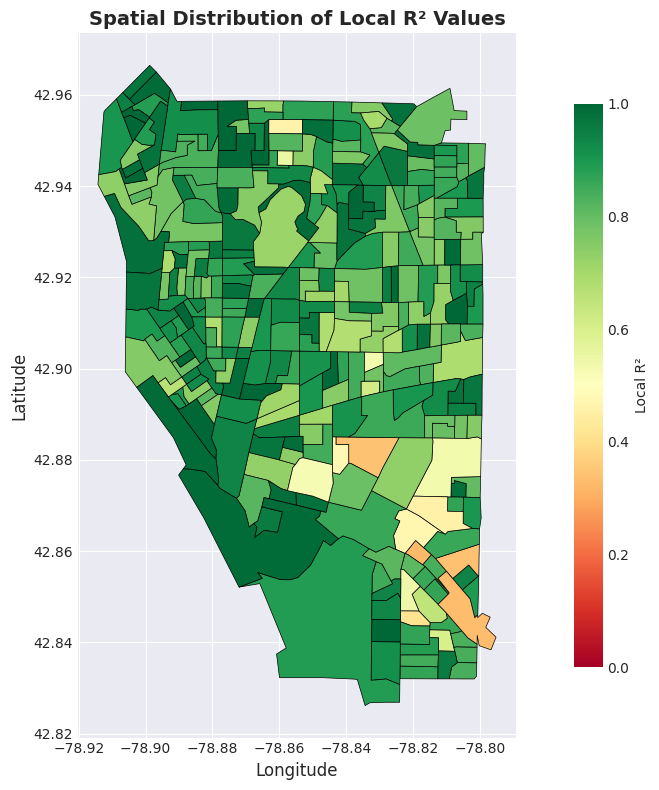

In [8]:
buffalo_cbgs = gpd.read_file('../data/buffalo/buffalo.shp')

# Create a DataFrame with GEO_ID and Local R² values
local_r2_data = pd.DataFrame({
    'GEO_ID': data['GEO_ID'].astype(str),
    'Local_R2': results.local_metrics
})

# Merge CBG geometries with Local R² data
buffalo_cbgs['GEOID'] = buffalo_cbgs['GEOID'].astype(str)
merged_cbgs = buffalo_cbgs.merge(local_r2_data, left_on='GEOID', right_on='GEO_ID')

fig, ax = plt.subplots(figsize=(12, 8))

merged_cbgs.plot(column='Local_R2', 
                 cmap='RdYlGn', 
                 ax=ax,
                 edgecolor='black', 
                 linewidth=0.5,
                 vmin=0, 
                 vmax=1,
                 legend=True,
                 legend_kwds={'label': 'Local R²', 'shrink': 0.8})

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Spatial Distribution of Local R² Values', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('../results/regression_r2.png', dpi=300, bbox_inches='tight')
plt.show()


### Spatial Variation in Feature Importance

Visualize how feature importance varies across space for the most important feature.


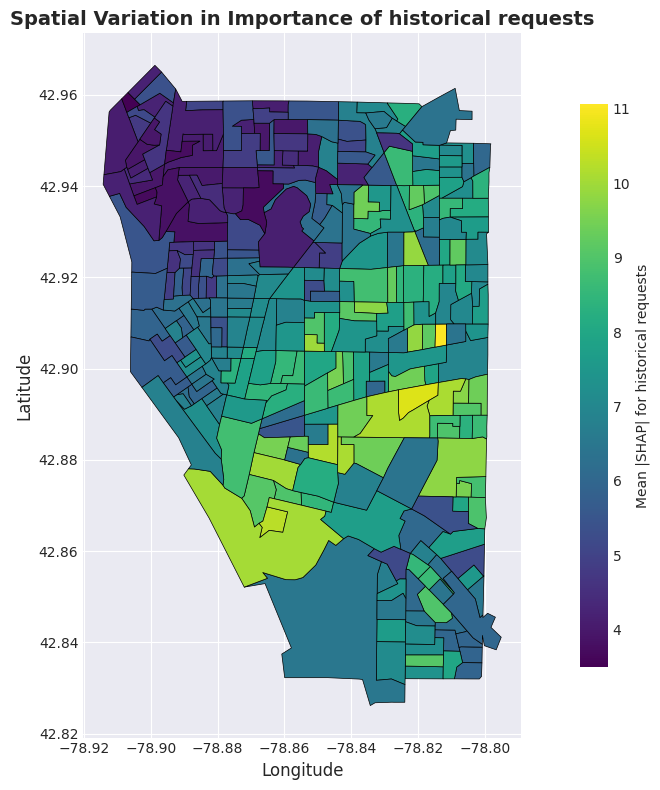

In [9]:
saved_results = load('../results/PyGALAX_regression_results.joblib')

# Extract SHAP values
mean_abs_shap = []
for loc_result in saved_results['location_results']:
    if 'raw_shap_values_neighbors' in loc_result and loc_result['raw_shap_values_neighbors'] is not None:
        shap_values = np.array(loc_result['raw_shap_values_neighbors'])
        if shap_values.ndim == 2:
            mean_abs_shap.append(np.mean(np.abs(shap_values), axis=0))

mean_abs_shap = np.array(mean_abs_shap)
global_importance = np.mean(mean_abs_shap, axis=0)
feature_names = x_vars if x_vars else [f'Feature {i}' for i in range(len(global_importance))]
sorted_idx = np.argsort(global_importance)[::-1][:10]

most_important_feature_idx = sorted_idx[0]
most_important_feature = feature_names[most_important_feature_idx]

# Extract mean absolute SHAP for this feature at each location
feature_shap_by_location = mean_abs_shap[:, most_important_feature_idx]

# Create a DataFrame with GEO_ID and feature importance values
feature_importance_data = pd.DataFrame({
    'GEO_ID': data['GEO_ID'].astype(str),
    'Feature_Importance': feature_shap_by_location
})

# Merge CBG geometries with feature importance data
buffalo_cbgs['GEOID'] = buffalo_cbgs['GEOID'].astype(str)
merged_cbgs_feature = buffalo_cbgs.merge(feature_importance_data, left_on='GEOID', right_on='GEO_ID')

fig, ax = plt.subplots(figsize=(12, 8))

merged_cbgs_feature.plot(column='Feature_Importance', 
                         cmap='viridis', 
                         ax=ax,
                         edgecolor='black', 
                         linewidth=0.5,
                         legend=True,
                         legend_kwds={'label': f'Mean |SHAP| for {most_important_feature}', 'shrink': 0.8})

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'Spatial Variation in Importance of {most_important_feature}', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('../results/regression_feature.png', dpi=300, bbox_inches='tight')
plt.show()
